In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [58]:
df = pd.read_csv("finally.csv")

In [59]:
df.head()

,CUSTOMER_ID,TOTAL_SPENDING,FREQUENCY,RETURN_RATIO,PURCHASE_INTENSITY,AVG_ORDER_VALUE,AVG_PURCHASE_GAP,ONE_TIME_CUSTOMER
0,12346.0,270.40,1,0.500000,6.000000,45.066667,45.000000,1
1,12747.0,59992.40,11,0.071730,21.545455,253.132489,36.300000,0
2,12748.0,1839408.35,216,0.068624,50.462963,168.753060,1.382488,0
3,12749.0,169590.85,7,0.061144,72.428571,334.498718,29.428571,0
4,12820.0,13109.20,4,0.093458,26.750000,122.515888,107.333333,0


<Axes: >

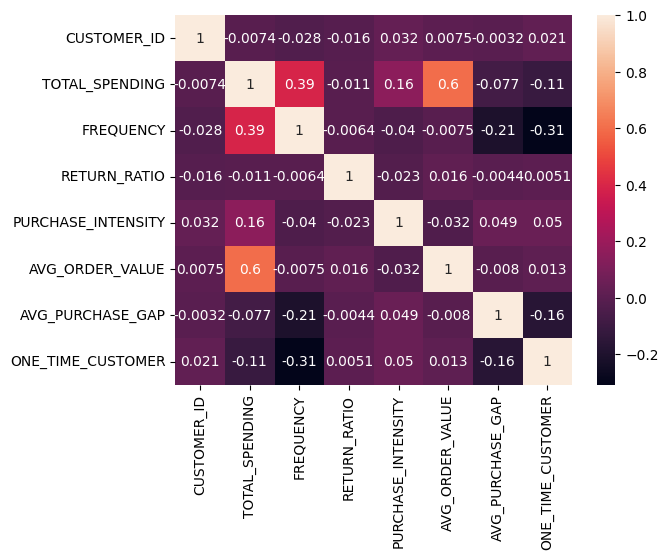

In [60]:
sns.heatmap(df.corr(numeric_only = True),annot = True)

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

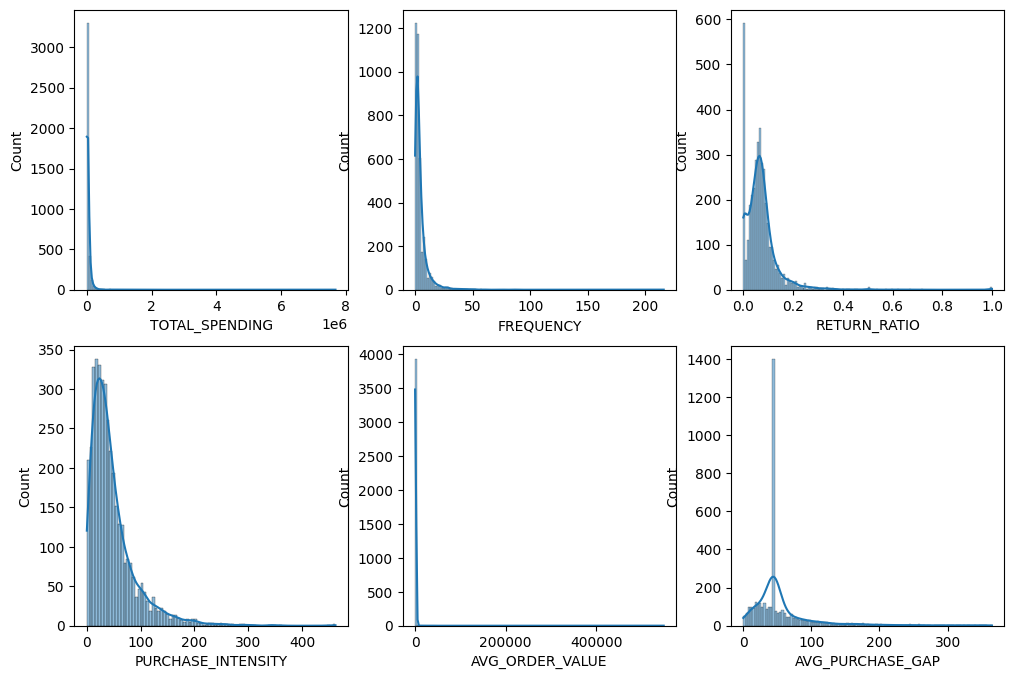

In [61]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df["AVG_PURCHASE_GAP"],kde = True)


In [62]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()
df4 = df.copy()

In [63]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    lower = df1[col].quantile(0.01)   
    upper = df1[col].quantile(0.99)  

    df1[col] = np.where(df1[col] < lower, lower, df1[col])
    df1[col] = np.where(df1[col] > upper, upper, df1[col])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

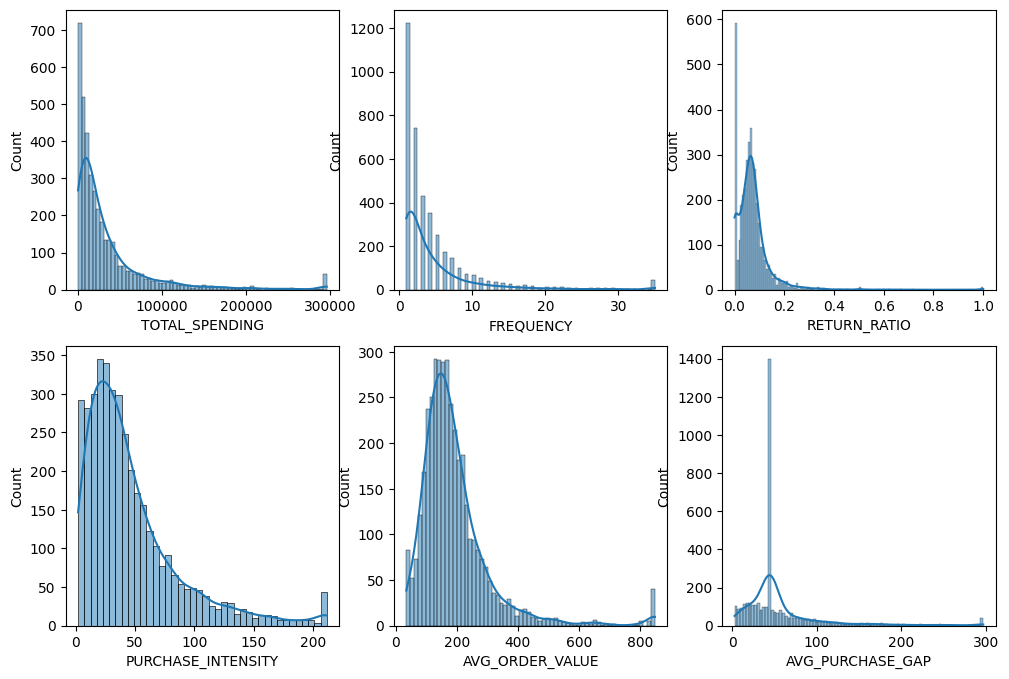

In [64]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df1["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df1["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df1["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df1["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df1["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df1["AVG_PURCHASE_GAP"],kde = True)

In [65]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    df2[col] = np.sqrt(df2[col])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

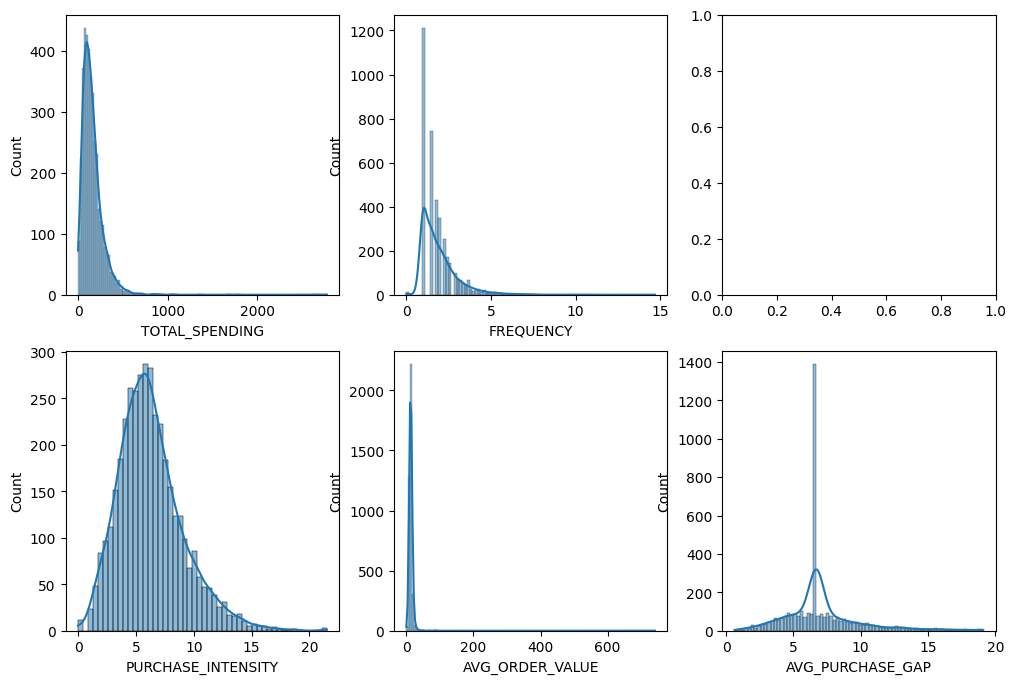

In [66]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df2["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df2["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
# sns.histplot(df2["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df2["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df2["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df2["AVG_PURCHASE_GAP"],kde = True)

In [67]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    lower = df3[col].quantile(0.01)   
    upper = df3[col].quantile(0.99)  

    df3[col] = np.where(df3[col] < lower, lower, df3[col])
    df3[col] = np.where(df3[col] > upper, upper, df3[col])

In [68]:
import numpy as np

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'PURCHASE_INTENSITY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    df3[col] = np.sqrt(df3[col])

In [69]:
import numpy as np


cap_cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'AVG_ORDER_VALUE'
]

for col in cap_cols:
    upper = df4[col].quantile(0.99)
    df4[col] = np.where(df4[col] > upper, upper, df4[col])


sqrt_cols = [
    'PURCHASE_INTENSITY',
    'AVG_PURCHASE_GAP'
]

for col in sqrt_cols:
    df4[col] = np.sqrt(df4[col])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

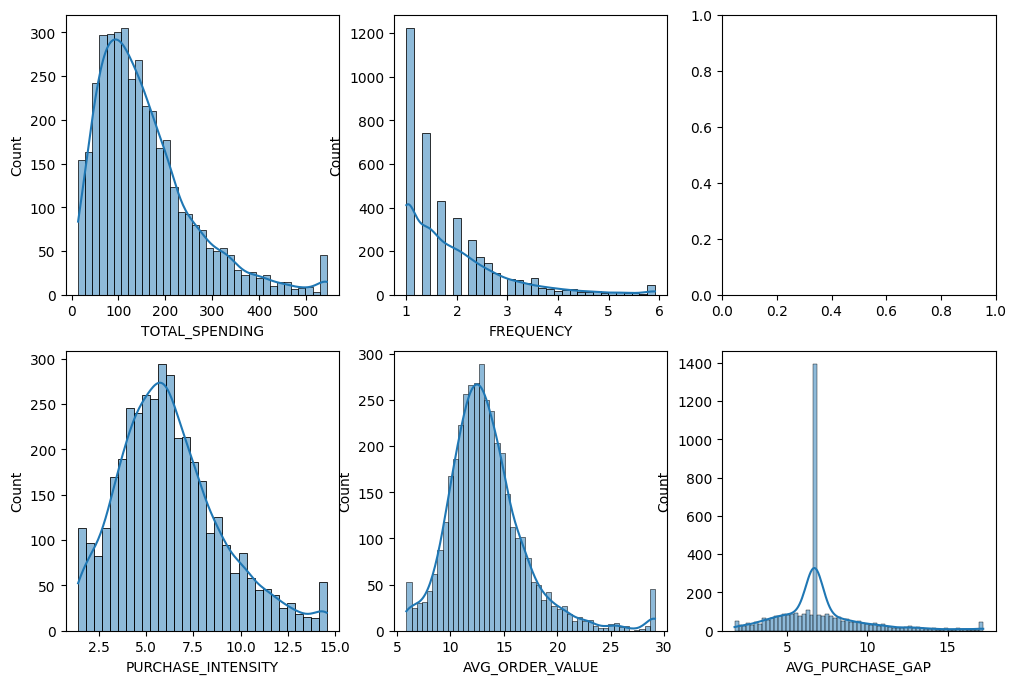

In [70]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df3["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df3["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
# sns.histplot(df2["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df3["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df3["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df3["AVG_PURCHASE_GAP"],kde = True)

In [71]:
features = ['TOTAL_SPENDING', 'FREQUENCY', 'RETURN_RATIO', 'AVG_PURCHASE_GAP', 'AVG_ORDER_VALUE',"ONE_TIME_CUSTOMER"]

In [72]:
X = df[features]
X1 = df1[features]
X2 = df2[features]
X3 = df3[features]
X4 = df4[features]

In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled1 = scaler.fit_transform(X1)
X_scaled2= scaler.fit_transform(X2)
X_scaled3 = scaler.fit_transform(X3)
X_scaled4 = scaler.fit_transform(X4)

In [74]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [75]:
wcss1 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled1)
    wcss1.append(kmeans.inertia_)

In [76]:
wcss2 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled2)
    wcss2.append(kmeans.inertia_)

In [77]:
wcss3 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled3)
    wcss3.append(kmeans.inertia_)

In [78]:
wcss4 = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled4)
    wcss4.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

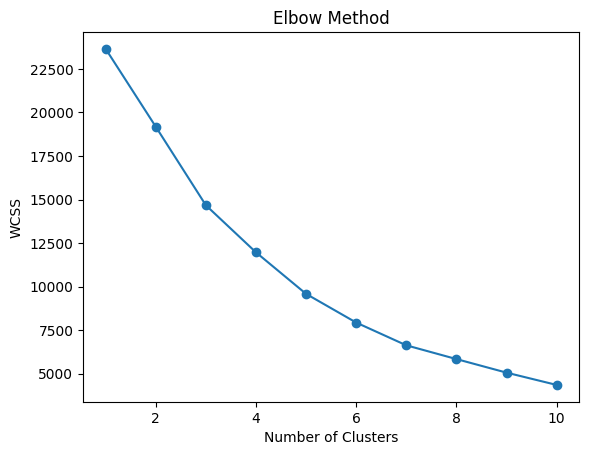

In [79]:

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")




Text(0, 0.5, 'WCSS')

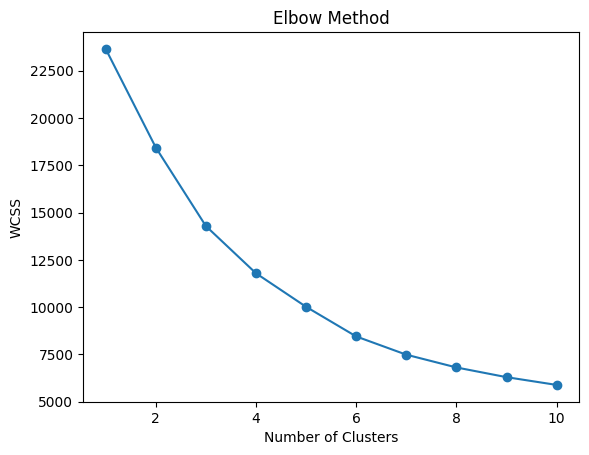

In [80]:
plt.figure()
plt.plot(range(1, 11), wcss1, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [81]:
k = 4  

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df1['Cluster'] = kmeans.fit_predict(X_scaled1)


In [82]:
score = silhouette_score(X_scaled1, df1['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.3745207713757584


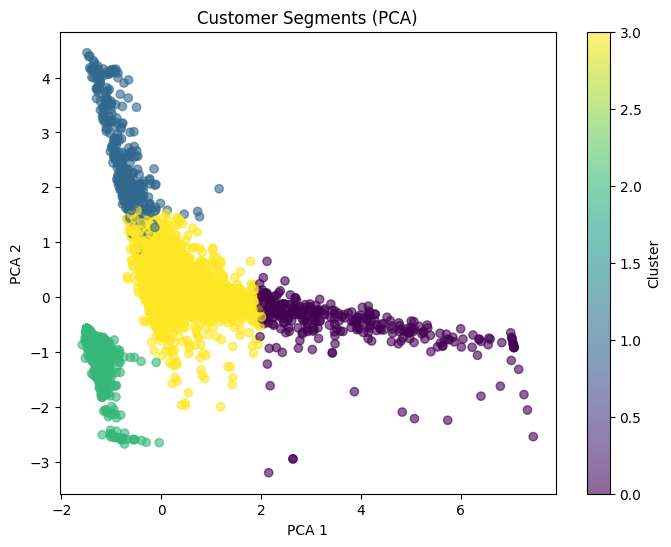

In [83]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled1)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df1['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [84]:
cluster_summary = df1.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_PURCHASE_GAP  \
Cluster                                                              
0         161792.053191  18.987842      0.073054         21.091303   
1          19024.988779   2.281609      0.069009        192.682950   
2           8835.733137   1.000000      0.071168         45.000000   
3          33250.655219   4.814689      0.071387         47.911299   

         AVG_ORDER_VALUE  ONE_TIME_CUSTOMER  
Cluster                                      
0             213.911851           0.009119  
1             183.719044           0.000000  
2             196.585707           1.000000  
3             190.069109           0.000000  


Text(0, 0.5, 'WCSS')

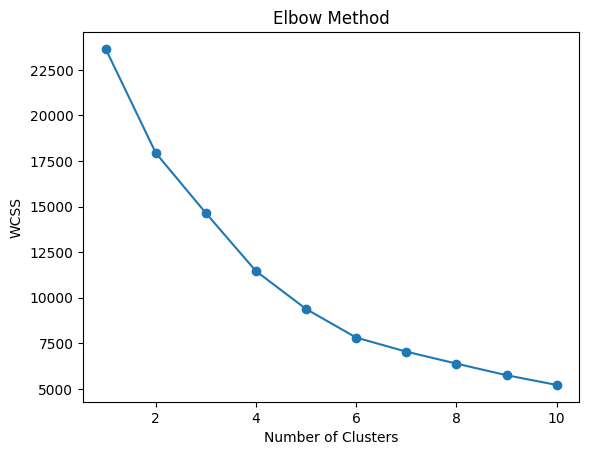

In [85]:
plt.figure()
plt.plot(range(1, 11), wcss2, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [86]:
k = 3  # change based on elbow/silhouette

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df2['Cluster'] = kmeans.fit_predict(X_scaled2)


In [87]:
score = silhouette_score(X_scaled2, df2['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.38701299806729594


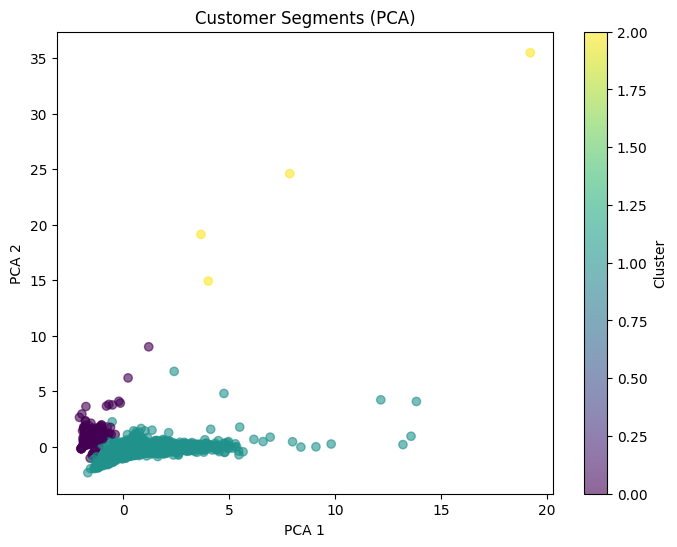

In [88]:
pca = PCA(n_components=2)
X_pca1 = pca.fit_transform(X_scaled2)

plt.figure(figsize=(8,6))
plt.scatter(X_pca1[:, 0], X_pca1[:, 1], c=df2['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [89]:
cluster_summary = df2.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_PURCHASE_GAP  \
Cluster                                                              
0             82.391502   0.991790      0.072226          6.708204   
1            192.066449   2.314661      0.070549          7.235494   
2           1246.463192   1.250000      0.250000          6.708204   

         AVG_ORDER_VALUE  ONE_TIME_CUSTOMER  
Cluster                                      
0              13.742072            0.99179  
1              13.573846            0.00000  
2             488.536045            0.75000  


Text(0, 0.5, 'WCSS')

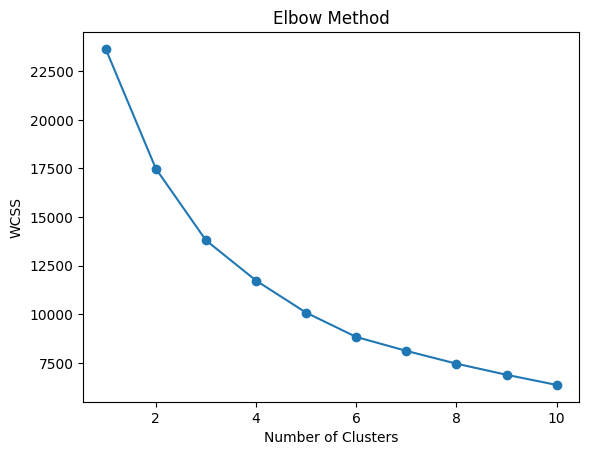

In [90]:
plt.figure()
plt.plot(range(1, 11), wcss3, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

In [91]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df3['Cluster'] = kmeans.fit_predict(X_scaled3)


In [92]:
score = silhouette_score(X_scaled3, df3['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.30915508631929767


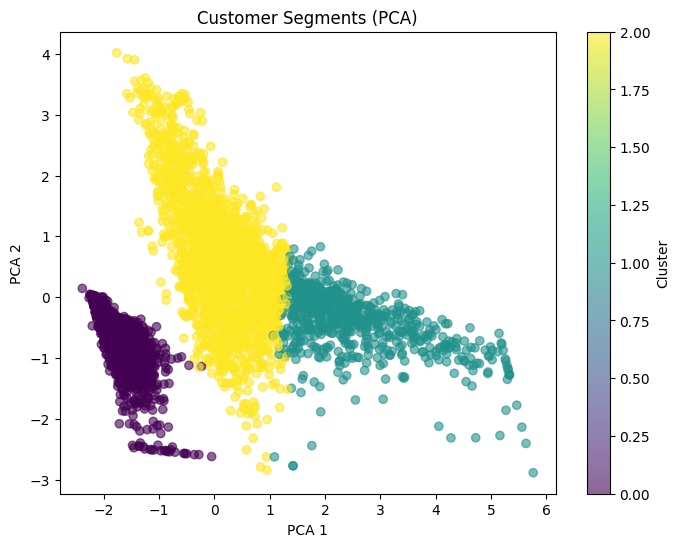

In [93]:
pca = PCA(n_components=2)
X_pca2 = pca.fit_transform(X_scaled3)

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=df3['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [94]:
cluster_summary = df3.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_PURCHASE_GAP  \
Cluster                                                              
0             83.101540   1.000000      0.071168          6.708204   
1            325.197450   3.616167      0.071610          4.942978   
2            144.051684   1.851766      0.071179          7.965303   

         AVG_ORDER_VALUE  ONE_TIME_CUSTOMER  
Cluster                                      
0              13.315912           1.000000  
1              14.077101           0.004478  
2              13.229331           0.000000  


Text(0, 0.5, 'WCSS')

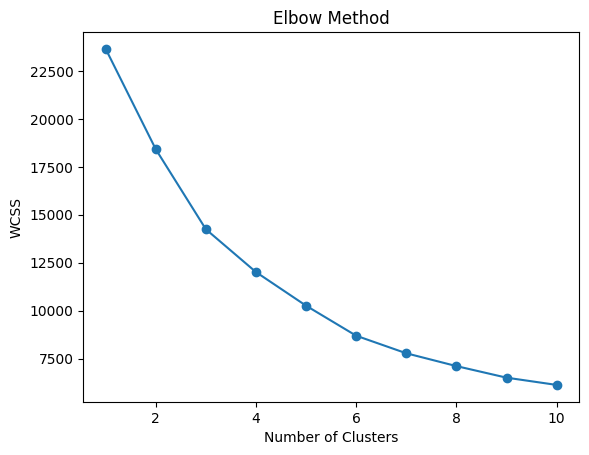

In [95]:
plt.figure()
plt.plot(range(1, 11), wcss4, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [96]:
k = 4 

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df4['Cluster'] = kmeans.fit_predict(X_scaled4)


In [97]:
score = silhouette_score(X_scaled4, df4['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.32590168736220143


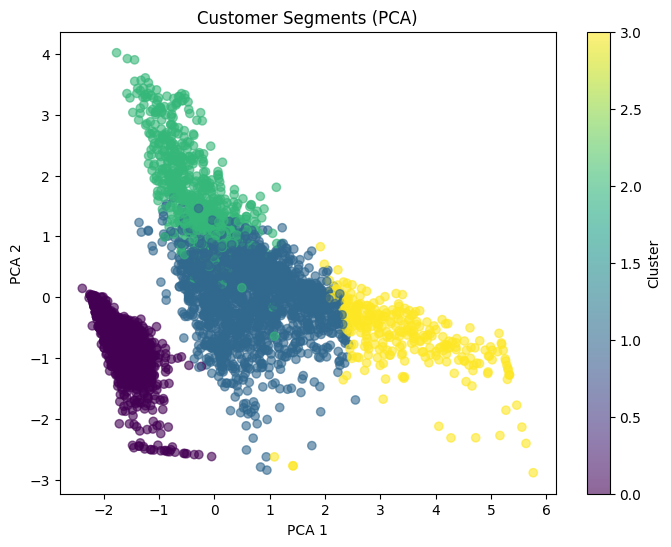

In [98]:
pca = PCA(n_components=2)
X_pca3 = pca.fit_transform(X_scaled3)

plt.figure(figsize=(8,6))
plt.scatter(X_pca3[:, 0], X_pca3[:, 1], c=df4['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [99]:
cluster_summary = df3.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_PURCHASE_GAP  \
Cluster                                                              
0             83.101540   1.000000      0.071168          6.708204   
1            325.197450   3.616167      0.071610          4.942978   
2            144.051684   1.851766      0.071179          7.965303   

         AVG_ORDER_VALUE  ONE_TIME_CUSTOMER  
Cluster                                      
0              13.315912           1.000000  
1              14.077101           0.004478  
2              13.229331           0.000000  
